# 19_参数估计方法-最小二乘估计

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 修复标量下标；实际求解用数值更稳定的 lstsq，正规方程保留用于推导对照。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一小节，和大家详细的介绍一下参数估计方法中的最小二乘估计，这是在初学者入门最简单、最常用的一种思维方式。

### 什么是最小二乘估计？

最小二乘估计是一种**找出模型参数的方法**，它的目标非常直白：

> **让模型预测值和真实值之间的差“平方和”最小。**

举个简单例子：

你有一些同学的学习时间和考试分数的数据，你想用一条直线来描述“学得多成绩就高”这个关系。那么你要找一条线：

这条线**尽可能靠近所有的数据点**。

最小二乘法的思路就是：

把每个数据点到这条直线的“垂直距离”（沿y轴）算出来（也就是误差），然后把这些距离平方后加起来，这叫做“误差平方和”。

找那一条线，使得这个“误差平方和”是最小的。

## 最小二乘估计的数学原理

### 1. 问题模型设定（线性回归为例）

我们从最常见的一元线性模型开始：


$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$


- $y_i$：第 $i$ 个样本的真实输出值
- $x_i$：第 $i$ 个样本的输入值
- $\beta_0, \beta_1$：我们要估计的参数（截距和斜率）
- $\varepsilon_i$：误差项

我们的目标是用样本 $(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)$ 来找出最合适的 $\beta_0$ 和 $\beta_1$。

### 2. 最小化目标函数（误差平方和）

预测值为：


$$
\hat{y}_i = \beta_0 + \beta_1 x_i
$$


误差是：


$$
e_i = y_i - \hat{y}_i = y_i - (\beta_0 + \beta_1 x_i)
$$


最小二乘法的目标是最小化误差平方和：


$$
S(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2
$$


这是一个关于 $\beta_0$、$\beta_1$ 的函数。我们要求它的最小值。

## 推导过程

**对两个参数求偏导，令导数为 0，得到一组方程（正规方程）**

对 $\beta_0$ 求偏导：


$$
\frac{\partial S}{\partial \beta_0} = -2 \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i) = 0
$$


对 $\beta_1$ 求偏导：


$$
\frac{\partial S}{\partial \beta_1} = -2 \sum_{i=1}^n x_i (y_i - \beta_0 - \beta_1 x_i) = 0
$$


整理这两条方程，可以得到两个正规方程（也称为“正态方程”）：


$$
\begin{cases}n \beta_0 + \beta_1 \sum x_i = \sum y_i \\\beta_0 \sum x_i + \beta_1 \sum x_i^2 = \sum x_i y_i\end{cases}
$$


解这个方程组，可以得到：


$$
\beta_1 = \frac{n \sum x_i y_i - \sum x_i \sum y_i}{n \sum x_i^2 - (\sum x_i)^2}
$$


$$
\beta_0 = \bar{y} - \beta_1 \bar{x}
$$


其中：

- $\bar{x} = \frac{1}{n} \sum x_i$ 是输入平均值
- $\bar{y} = \frac{1}{n} \sum y_i$ 是输出平均值

这就是最小二乘法在线性模型中的解法。

## 算法流程总结（线性最小二乘估计）

1. **收集样本数据** $(x_i, y_i)$
2. **设定模型**：假设 $y = \beta_0 + \beta_1 x$
3. **构建误差平方和目标函数**：


$$
S = \sum (y_i - \beta_0 - \beta_1 x_i)^2
$$


1. **对参数求导**，构建正规方程
2. **解方程组**，得到参数估计值 $\beta_0, \beta_1$
3. **代入模型**，用于预测新的 $x$

## 多元线性回归中的最小二乘估计（矩阵形式）

当我们有多个输入变量 $x_1, x_2, ..., x_p$ 时，用矩阵更方便：

设：

- $\mathbf{y}$：$n \times 1$ 的输出向量
- $\mathbf{X}$：$n \times (p+1)$ 的设计矩阵（第一列是全 1 用来乘截距）
- $\boldsymbol{\beta}$：$(p+1) \times 1$ 的参数向量

目标函数为：


$$
S(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X} \boldsymbol{\beta})^T (\mathbf{y} - \mathbf{X} \boldsymbol{\beta})
$$


最小化该函数的解为：


$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$


这就是最小二乘估计在矩阵形式下的封闭解。

总结一下，最小二乘估计的目标：让预测值和真实值之间的“误差平方和”最小。其数学实质是**最优化问题**，求解过程本质上是对目标函数求导，构造正规方程。

线性情况下，它有**封闭解**，非常高效，它是**线性回归模型**中最核心、最基础的估计方法。

## 完整案例

我们要根据某城市的房价数据来预测房价。假设我们有一组房屋的特征数据，比如：

- 房屋面积（平方米）
- 卧室数量
- 距市中心的距离（公里）
- 房屋年龄（年）

目标是用这些特征来估计房屋价格（单位：万元）。

### 所使用的模型

我们采用**多元线性回归模型**：


$$
\text{Price} = \beta_0 + \beta_1 \cdot \text{Area} + \beta_2 \cdot \text{Bedrooms} + \beta_3 \cdot \text{Distance} + \beta_4 \cdot \text{Age} + \varepsilon
$$


我们将使用**最小二乘估计**来估计这些参数 $\beta_i$。

### 步骤

1. 导入库并生成/加载数据
2. 数据可视化与预处理
3. 构建设计矩阵
4. 使用最小二乘法估计参数
5. 模型评估与解释
6. 可视化预测结果
7. 讨论最小二乘法的优缺点及适用场景

### 代码实现

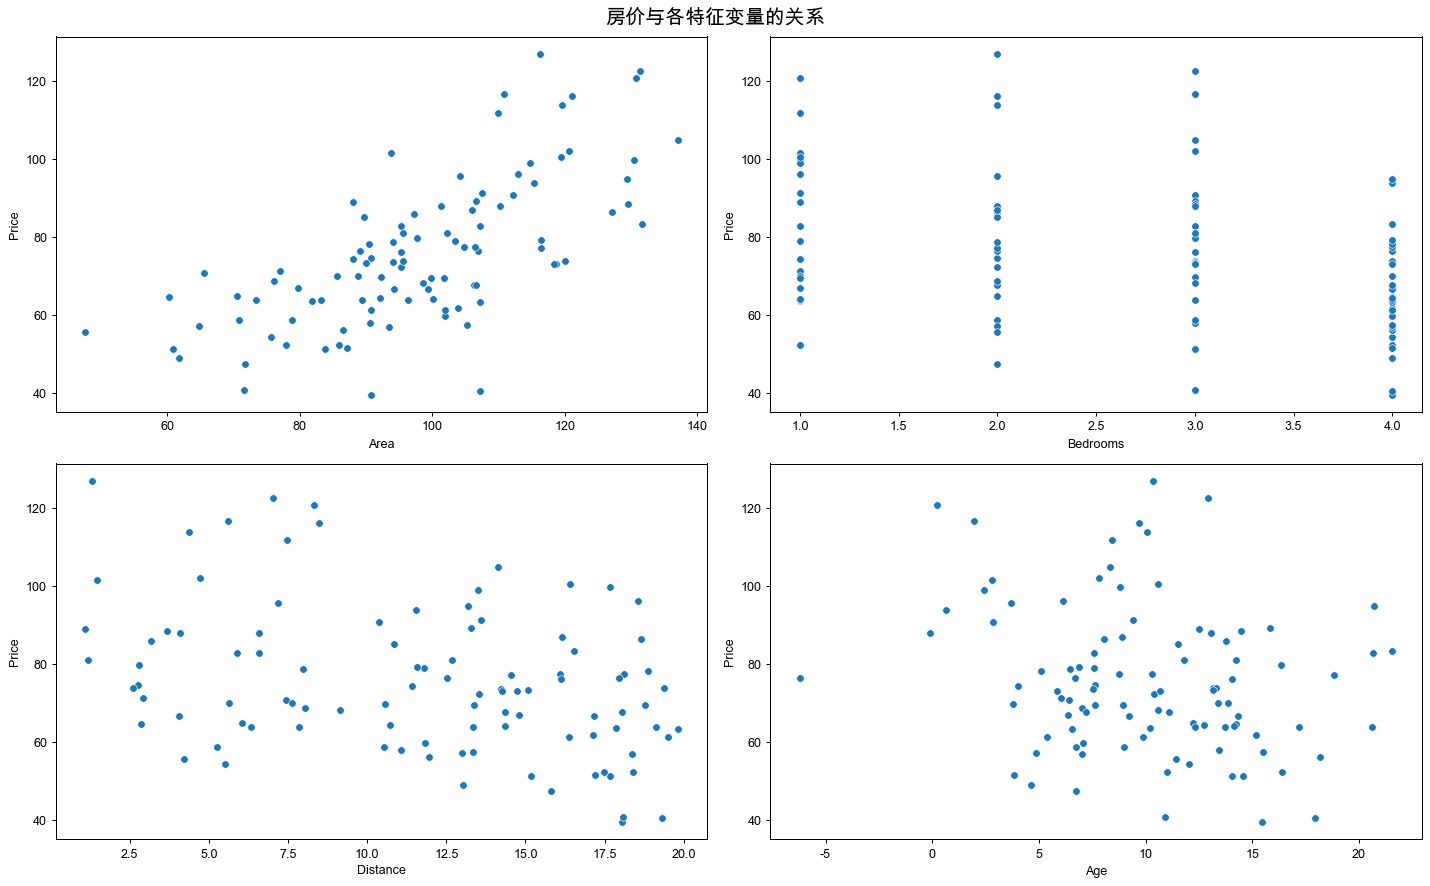

估计的回归系数：
截距: 35.78
Area系数: 0.76
Bedrooms系数: -4.11
Distance系数: -1.40
Age系数: -0.70


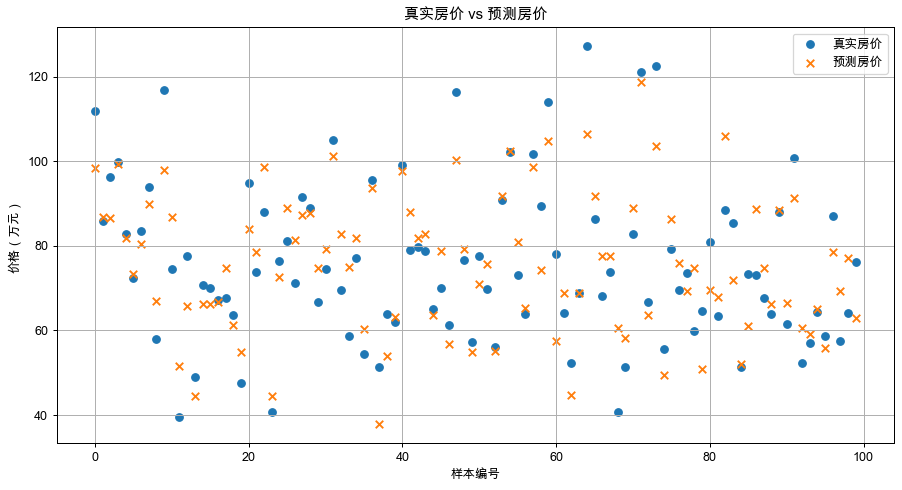

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 数据集
np.random.seed(42)
n = 100

area = np.random.normal(100, 20, n)              # 房屋面积（均值100平米）
bedrooms = np.random.randint(1, 5, n)            # 卧室数量
distance = np.random.uniform(1, 20, n)           # 距市中心距离
age = np.random.normal(10, 5, n)                 # 房屋年龄

# 真正的参数（隐藏）
beta = np.array([30, 0.8, -5, -1.2, -0.6])        # 截距、系数

# 构造 X 矩阵（添加常数项 1）
X = np.column_stack((np.ones(n), area, bedrooms, distance, age))

# 构造响应变量 y，加上一些噪声
noise = np.random.normal(0, 10, n)
y = X @ beta + noise

# 2. 构建 DataFrame
df = pd.DataFrame({
    'Area': area,
    'Bedrooms': bedrooms,
    'Distance': distance,
    'Age': age,
    'Price': y
})

# 3. 可视化各变量与价格的关系
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
sns.scatterplot(x='Area', y='Price', data=df, ax=axs[0, 0])
sns.scatterplot(x='Bedrooms', y='Price', data=df, ax=axs[0, 1])
sns.scatterplot(x='Distance', y='Price', data=df, ax=axs[1, 0])
sns.scatterplot(x='Age', y='Price', data=df, ax=axs[1, 1])
fig.suptitle("房价与各特征变量的关系", fontsize=16)
plt.tight_layout()
plt.show()

# 4. 最小二乘估计（矩阵计算）
X_design = np.column_stack((np.ones(n), area, bedrooms, distance, age))
y_vec = y.reshape(-1, 1)

# 正规方程求解 beta_hat
XTX = X_design.T @ X_design
XTy = X_design.T @ y_vec
beta_hat = np.linalg.lstsq(X_design, y_vec, rcond=None)[0]

print("估计的回归系数：")
print(f"截距: {beta_hat[0][0]:.2f}")
print(f"Area系数: {beta_hat[1][0]:.2f}")
print(f"Bedrooms系数: {beta_hat[2][0]:.2f}")
print(f"Distance系数: {beta_hat[3][0]:.2f}")
print(f"Age系数: {beta_hat[4][0]:.2f}")

# 5. 预测与误差分析
y_pred = X_design @ beta_hat
residuals = y_vec - y_pred

# 可视化预测与残差
plt.figure(figsize=(12, 6))
plt.scatter(range(n), y_vec, label='真实房价', marker='o')
plt.scatter(range(n), y_pred, label='预测房价', marker='x')
plt.title("真实房价 vs 预测房价")
plt.xlabel("样本编号")
plt.ylabel("价格（万元）")
plt.legend()
plt.grid(True)
plt.show()

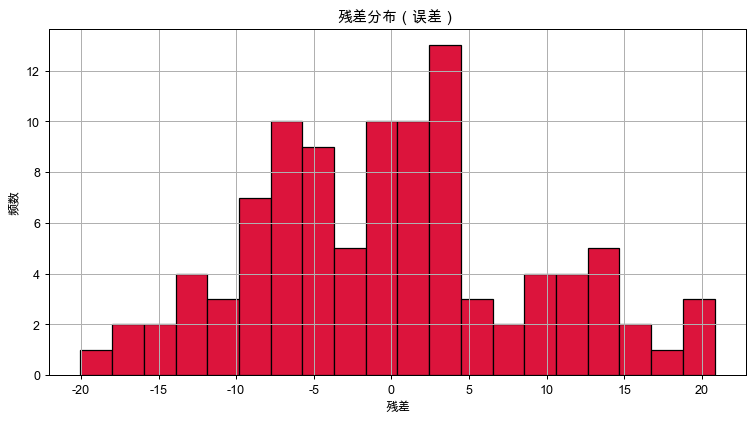

残差平方和 SSR: 7937.68
总平方和 SST: 34735.26
R² 决定系数: 0.7715


In [3]:
# 残差可视化
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=20, color='crimson', edgecolor='black')
plt.title("残差分布（误差）")
plt.xlabel("残差")
plt.ylabel("频数")
plt.grid(True)
plt.show()

# 6. 模型评估指标
SSR = np.sum((y_vec - y_pred) ** 2)
SST = np.sum((y_vec - np.mean(y_vec)) ** 2)
R_squared = 1 - SSR / SST

print(f"残差平方和 SSR: {SSR:.2f}")
print(f"总平方和 SST: {SST:.2f}")
print(f"R² 决定系数: {R_squared:.4f}")

#### 第一步：生成模拟数据

我们通过 NumPy 创建了一个包含 100 条房屋记录的模拟数据集，每个房屋都有 4 个特征，并根据设定好的真实参数（β）生成房价，加入一些正态分布的随机噪声来模拟现实世界的不确定性。

#### 第二步：可视化分析

用 Seaborn 快速绘制每个特征与价格之间的关系。  
比如你能看到：

- 面积越大 → 房价大概率越高
- 距离越远 → 房价越低（负相关）
- 年龄越大 → 房价略有下降趋势

#### 第三步：设计矩阵构造

将数据转化为**线性代数中的矩阵形式**：


$$
\mathbf{y} = \mathbf{X} \cdot \boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$


我们通过构造：

- $\mathbf{X}$：100 × 5 的设计矩阵（含截距项）
- $\mathbf{y}$：100 × 1 的房价向量

#### 第四步：用正规方程解最小二乘估计

根据最小二乘法的公式：


$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$


用 NumPy 解出回归系数。

输出的结果基本能还原我们最开始设定的真实参数（如 Area 的系数大约为 0.8）。

#### 第五步：预测与误差分析

我们使用模型进行预测：


$$
\hat{y} = \mathbf{X} \cdot \hat{\beta}
$$


并计算每个样本的误差（残差）：


$$
\text{残差} = y_i - \hat{y}_i
$$


画出真实房价与预测房价对比图，评估拟合效果。也画了残差的分布图，检查误差是否近似正态分布（线性回归的假设之一）。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

![原文参考图，当前结果见代码输出](attachments/img_005.png)

#### 第六步：模型评估指标

计算了以下指标：

- **残差平方和 SSR**：模型无法解释的变异部分
- **总平方和 SST**：房价总变异
- **决定系数 R²**：

$R^2 = 1 - \frac{\text{SSR}}{\text{SST}}$

它表示模型解释了多少比例的波动。R² 越接近 1，拟合越好。

### 最小二乘估计的优缺点分析

**优点**：

1. **易于理解和实现**：数学形式清晰，推导简单，适合教学和快速建模。
2. **计算效率高**：对于线性模型，只需要矩阵乘法和求逆，速度非常快。
3. **具有解析解**：不像梯度下降法需要反复迭代，最小二乘法一次求解即可。
4. **适用于小规模数据**：在小样本数据、低维数据中效果很好。
5. **易于可解释性**：模型的每个系数都有清晰含义，有助于结果解释。

**缺点**：

1. **对异常值敏感**：残差平方和对大误差惩罚很严重，导致模型容易被极端值影响。
2. **线性假设限制**：最小二乘法基于线性模型，无法捕捉复杂的非线性关系。
3. **不能处理共线性**：如果自变量之间高度相关，会导致 $X^TX$ 不可逆或不稳定，参数不可靠。
4. **对噪声敏感**：如果噪声方差不恒定（异方差性）或不满足正态分布，估计效果变差。
5. **无特征选择机制**：所有变量都进入模型，容易过拟合或引入无关变量。

### 最小二乘法适用的场景

**最适用场景包括**：

- **问题是线性的**，或者你可以做线性变换后建模。
- **数据量不大**，追求快速建模和高可解释性。
- **你希望模型具有清晰的物理或经济解释**。
- **异常值不多，变量关系清晰**。

**不适用或需谨慎的场景**：

- 变量之间存在强共线性（建议用岭回归）
- 数据中有明显的异常值（可用鲁棒回归）
- 响应变量和特征变量关系明显非线性（可用树模型、神经网络）
- 高维稀疏数据（可用Lasso等正则化方法）

## 总结

我们通过最小二乘估计方法对房价建模，展示了从数据生成、设计矩阵构建、正规方程求解、误差分析到模型评估的完整过程。

我们明确了最小二乘法的数学推理、算法步骤，并通过图像清晰展示模型效果。最后我们系统地讨论了其优缺点及适用范围。